# Historical ENTSOE Wind Production (2019–2025)

This notebook loads and processes the ENTSOE Transparency Platform CSV exports to produce a clean hourly wind production series for Estonia covering the GNN training period.

**Output:** `data/entsoe_production_hourly.csv` — used by `Supply.py` to add `wind_mw` as an explicit input feature to the ST-GNN.

**Counterfactual scenarios** are handled in a separate notebook: `ursula_wind_counterfactual.ipynb`.

---

## Why actual ENTSOE production data, not weather re-estimation?

For the **training period (2019–2025)**, the right data source is the ENTSOE CSV exports — not weather-derived estimates.

The ENTSOE files contain actual **metered production** from the Estonian grid, including curtailments, maintenance outages, and grid constraints. If we estimated from weather instead, we'd get smooth theoretical output that never captures real-world reductions — making the GNN learn a cleaner wind–price relationship than actually exists.

## Why wind as a GNN feature, and not solar or biomass too?

**Wind is the scenario variable.** Scenarios S3 and S4 simulate adding 323 MW and 564 MW of new wind capacity. For the model to learn that *more wind → lower prices*, wind must be an **explicit input feature** — if it's buried inside `production_renewable`, the model can't isolate the signal when we inject the counterfactual series.

**Solar contributes almost nothing in January.** The test period is January 2026; Estonian solar output is near zero in winter (~0–5 MW).

**Biomass is dispatchable, not weather-driven.** It's scheduled like baseload and is already captured implicitly via `production_renewable` and `production`.

**Multicollinearity risk.** `production_renewable` already aggregates wind + solar + biomass. Adding individual columns on top without substantially more data risks confusing the weight learning.

**Conclusion: add only `wind_mw` as a new feature.**


## Historical ENTSOE Wind Production (2019–2025)

### Data format

The ENTSOE files are in **long format**: one row per (hour, production type). Each file covers roughly one calendar year and contains ~20 production types (Biomass, Wind Onshore, Solar, Fossil Oil shale, Fossil Gas, etc.) for Estonia (`CTA|EE`).

Key column structure:
```
"MTU (CET/CEST)"                                    "Area"    "Production Type"  "Generation (MW)"
"01/01/2024 00:00:00 - 01/01/2024 01:00:00"         "CTA|EE"  "Biomass"          "51.00"
"01/01/2024 00:00:00 - 01/01/2024 01:00:00"         "CTA|EE"  "Wind Onshore"     "238.30"
```

Each hour therefore appears as ~20 rows (one per type). The pivot step (1c) reshapes this to one row per hour, one column per type.

### Steps at a glance

| Step | What it does |
|---|---|
| 1a | Load & parse all 7 CSVs, convert timestamps to UTC |
| 1b | Coerce `"n/e"` strings to NaN |
| 1c | Drop Wind Offshore (all NaN for Estonia), pivot to wide format |
| 1d | Deduplicate year-boundary overlaps, resample to clean hourly UTC index |
| 1e | Validate with assertions and seasonal plots |
| 1f | Compute capacity factor (actual MW ÷ installed MW) |
| 1g | Save to `data/entsoe_production_hourly.csv` |


In [88]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../data/historical_production_data/"

# Explicitly exclude the 2026 file — it covers the held-out test period (Jan 2026)
# and should never be included in training data.
files = sorted([
    f for f in glob.glob(DATA_DIR + "*.csv")
    if not os.path.basename(f).startswith("2026")
])
print(f"Found {len(files)} ENTSOE CSV files (2019–2025 only):")
for f in files:
    print(" ", os.path.basename(f))

Found 7 ENTSOE CSV files (2019–2025 only):
  2019_AGGREGATED_GENERATION_PER_TYPE_GENERATION_201812312300-201912312300.csv
  2020_AGGREGATED_GENERATION_PER_TYPE_GENERATION_201912312300-202012312300.csv
  2021_AGGREGATED_GENERATION_PER_TYPE_GENERATION_202012312300-202112312300.csv
  2022_AGGREGATED_GENERATION_PER_TYPE_GENERATION_202112312300-202212312300.csv
  2023_AGGREGATED_GENERATION_PER_TYPE_GENERATION_202212312300-202312312300.csv
  2024_AGGREGATED_GENERATION_PER_TYPE_GENERATION_202312312300-202412312300.csv
  2025_AGGREGATED_GENERATION_PER_TYPE_GENERATION_202412312300-202512312300.csv


### Step 1a — Load all 7 CSVs and parse timestamps

**The timestamp problem.** ENTSOE encodes each hour as a `"start - end"` interval string. Most rows look like `"01/01/2024 00:00:00 - 01/01/2024 01:00:00"`, but on the two DST transition days per year the format changes:

- **Spring forward** (clocks skip 03:00 → 04:00): `"31/03/2019 01:00:00 (CET) - 31/03/2019 03:00:00 (CEST)"` — the timezone abbreviation appears in the string to signal that an hour is being skipped.
- **Fall back** (clocks repeat 03:00 → 02:00 → 03:00): the ambiguous hour appears *twice*, once labeled `(CEST)` (summer, UTC+3) and once `(EET)` (standard, UTC+2).

**Why `ambiguous="infer"` fails on fall-back.** The `"infer"` mode tries to detect DST from the order of the timestamps. But the fall-back hour (03:00) appears twice with the *same* naive datetime string — pandas can't tell them apart from order alone and raises `AmbiguousTimeError`.

**Fix: build an explicit boolean array.** We read the timezone suffix directly from the raw MTU string. Rows with `(CET)` or `(EET)` are standard time → `ambiguous=False`. Everything else (summer-labeled or no label at all) → `ambiguous=True`. Since only the ambiguous fall-back hour has two rows with conflicting suffixes, this correctly routes the first occurrence to EEST and the second to EET.

**Spring-forward gap** (the skipped hour) is handled by `nonexistent="shift_forward"`, which shifts any non-existent local time forward past the gap.

In [89]:
# 1a. Load all 7 ENTSOE CSVs
# Normal rows:      "01/01/2024 00:00:00 - 01/01/2024 01:00:00"
# DST spring-fwd:   "31/03/2019 01:00:00 (CET) - 31/03/2019 03:00:00 (CEST)"
# DST fall-back:    "27/10/2019 02:00:00 (CEST) - 27/10/2019 02:00:00 (EET)"
#                   "27/10/2019 03:00:00 (EET)  - 27/10/2019 04:00:00 (EET)"
#
# Strategy: extract (CET/EET) vs (CEST/EEST) suffix → explicit is_dst boolean array
# so tz_localize can correctly disambiguate the fall-back duplicate hour.

frames = []
for f in files:
    df = pd.read_csv(f, quotechar='"')
    df.columns = ["mtu", "area", "ptype", "mw"]

    mtu_start = df["mtu"].str.split(" - ").str[0]   # "01/01/2024 00:00:00" or "...01:00:00 (CET)"

    # Identify rows explicitly marked as standard time → DST=False
    is_standard = mtu_start.str.contains(r"\(CET\)|\(EET\)", regex=True, na=False)
    # All other rows (summer-labeled or unlabeled) → DST=True (default; unambiguous rows ignore it)
    ambiguous_arr = np.where(is_standard, False, True)

    ts_clean = (
        mtu_start
        .str.replace(r"\s*\(\w+\)", "", regex=True)
        .str.strip()
    )
    df["ts"] = pd.to_datetime(ts_clean, format="%d/%m/%Y %H:%M:%S")

    df["ts"] = (
        df["ts"]
        .dt.tz_localize("Europe/Tallinn", ambiguous=ambiguous_arr, nonexistent="shift_forward")
        .dt.tz_convert("UTC")
    )

    frames.append(df[["ts", "ptype", "mw"]])

raw = pd.concat(frames, ignore_index=True)
print("Production types found:")
print(raw["ptype"].unique())
print(f"\nTimestamp range: {raw['ts'].min()} → {raw['ts'].max()}")
print(f"Total rows: {len(raw):,}")

Production types found:
['Biomass' 'Energy storage' 'Fossil Brown coal/Lignite'
 'Fossil Coal-derived gas' 'Fossil Gas' 'Fossil Hard coal' 'Fossil Oil'
 'Fossil Oil shale' 'Fossil Peat' 'Geothermal' 'Hydro Pumped Storage'
 'Hydro Run-of-river and pondage' 'Hydro Water Reservoir' 'Marine'
 'Nuclear' 'Other' 'Other renewable' 'Solar' 'Waste' 'Wind Offshore'
 'Wind Onshore']

Timestamp range: 2018-12-31 22:00:00+00:00 → 2025-12-31 21:00:00+00:00
Total rows: 1,288,728


In [90]:
# 1b. Handle special values
# "n/e" = not existing (e.g. Wind Offshore for Estonia) → coerce to NaN
raw["mw"] = pd.to_numeric(raw["mw"], errors="coerce")

# Confirm Wind Offshore is all NaN (Estonia has no offshore wind)
offshore = raw[raw["ptype"] == "Wind Offshore"]["mw"]
print(f"Wind Offshore rows: {len(offshore)}, non-NaN: {offshore.notna().sum()}")

Wind Offshore rows: 61368, non-NaN: 0


### Step 1b — Handle `"n/e"` and missing values

The `"Generation (MW)"` column uses the string `"n/e"` (not existing) for production types that don't operate in Estonia — the most important example being **Wind Offshore**, **since Estonia has no offshore wind farms yet**. `pd.to_numeric(errors="coerce")` converts these to `NaN`, which we then handle in the next step.

Note: zero values are valid (a wind farm producing nothing in calm conditions), but `NaN` means the type genuinely doesn't exist and shouldn't be included in aggregates.

In [91]:
# 1c. Drop Wind Offshore, pivot to wide format
raw = raw[raw["ptype"] != "Wind Offshore"]

production = (
    raw
    .pivot_table(index="ts", columns="ptype", values="mw", aggfunc="mean")
    .sort_index()
)

# Clean column names
production.columns = (
    production.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("/", "_", regex=False)
)

print("Columns:", list(production.columns))
print(f"Shape before dedup: {production.shape}")

Columns: ['biomass', 'fossil_coal-derived_gas', 'fossil_gas', 'fossil_oil_shale', 'fossil_peat', 'hydro_run-of-river_and_pondage', 'other', 'other_renewable', 'solar', 'waste', 'wind_onshore']
Shape before dedup: (61350, 11)


### Step 1c — Pivot to wide format

`pivot_table` reshapes from long format (one row per hour × type) to wide format (one row per hour, one column per type). The result is a proper time-series DataFrame that the GNN can consume.

We use `aggfunc="mean"` rather than `"sum"` as a safeguard — if a duplicate (timestamp, type) pair somehow appears, it averages rather than double-counting. In practice, each (timestamp, type) pair should be unique after the year-boundary deduplication in step 1d.

Column names are cleaned to lowercase + underscores so they work as Python identifiers and match the naming convention in `Supply.py`.

In [92]:
# 1d. Deduplicate year-boundary overlap, resample to clean hourly UTC index
# Each file starts with the last hour of the prior year → duplicates at year boundaries
production = production[~production.index.duplicated(keep="first")]
production = production.resample("h").mean()   # fills accidental gaps with NaN

print(f"Shape after dedup + resample: {production.shape}")
print(f"Date range: {production.index.min()} → {production.index.max()}")
print("\nNaN count per column:")
print(production.isna().sum())

Shape after dedup + resample: (61368, 11)
Date range: 2018-12-31 22:00:00+00:00 → 2025-12-31 21:00:00+00:00

NaN count per column:
ptype
biomass                           34
fossil_coal-derived_gas           34
fossil_gas                        34
fossil_oil_shale                  34
fossil_peat                       34
hydro_run-of-river_and_pondage    34
other                             34
other_renewable                   34
solar                             20
waste                             34
wind_onshore                      41
dtype: int64


### Step 1d — Deduplicate and resample

**Year-boundary overlap.** Each ENTSOE file starts with the last hour of the *prior* year. For example, the 2020 file begins at `2019-12-31 22:00 UTC` — the same timestamp that ends the 2019 file. After concatenating all 7 files, these boundary hours appear twice. `~index.duplicated(keep="first")` removes the second occurrence.

**Resample to `"h"`** ensures the index is perfectly regular with no gaps. If a timestamp is missing from the raw ENTSOE data (occasional reporting gaps), `resample("h").mean()` fills the slot with `NaN` rather than silently misaligning all subsequent rows. The NaN count after resampling (~34 per column) reflects these raw data gaps — they are spread across all years and are not related to DST transitions.

**Why UTC throughout?** The Elering API data (which the GNN uses for prices and flows) is returned in UTC. Keeping everything in UTC means a simple `reindex()` will align the two datasets without timezone confusion.


wind_onshore stats:
count    61327.000000
mean       102.357906
std         90.422202
min          0.000000
25%         34.700000
50%         74.500000
75%        147.200000
max        588.400000
Name: wind_onshore, dtype: float64


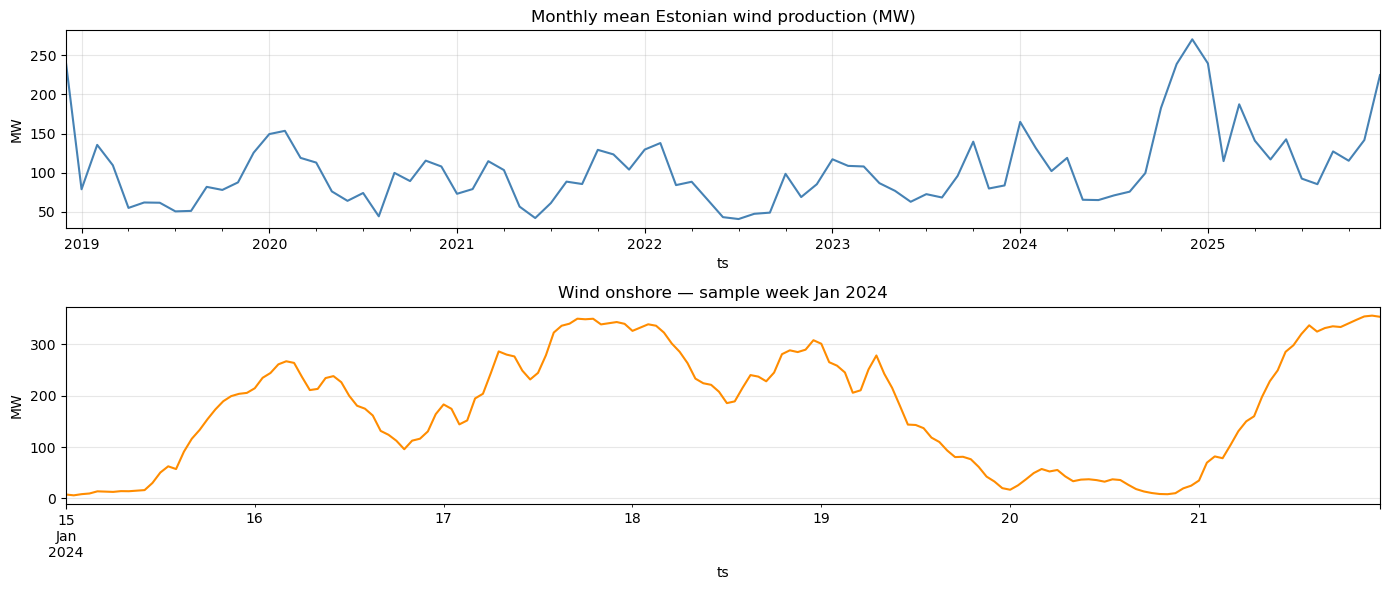

In [93]:
# 1e. Validate wind_onshore
wind = production["wind_onshore"]

assert wind.dropna().min() >= 0, f"Negative wind production found: {wind.min()}"
# Max installed capacity reached ~694 MW in 2025; anything above 750 MW is a data error
assert wind.dropna().max() < 750, f"Implausibly high wind: {wind.max()} MW (installed capacity ~694 MW)"

print("wind_onshore stats:")
print(wind.describe())

# Monthly mean — should peak Oct-Feb, dip Jul-Aug
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

wind.resample("ME").mean().plot(
    ax=axes[0],
    title="Monthly mean Estonian wind production (MW)",
    color="steelblue"
)
axes[0].set_ylabel("MW")
axes[0].grid(True, alpha=0.3)

# Sample week Jan 2024
wind["2024-01-15":"2024-01-21"].plot(
    ax=axes[1],
    title="Wind onshore — sample week Jan 2024",
    color="darkorange"
)
axes[1].set_ylabel("MW")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Step 1e — Validate and visualise

Two sanity checks and two plots. The assertions catch obviously broken data before it silently corrupts training:
- `min >= 0`: wind production can't be negative — any negative value means a unit conversion or sign error.
- `max < 750`: installed capacity reached ~694 MW in 2025; a value above 750 MW would indicate a data error (e.g. merging production from multiple countries).

**What to look for in the plots:**
- *Monthly mean*: should show a clear winter peak (Oct–Feb) and summer dip (Jul–Aug), consistent with the Baltic wind climate. A flat or inverted pattern would indicate a timestamp or timezone error.
- *Sample week*: hourly variability should be large — rapid swings from near zero to several hundred MW within a few hours, reflecting real synoptic weather. Suspiciously smooth output would suggest data is aggregated at the wrong frequency.


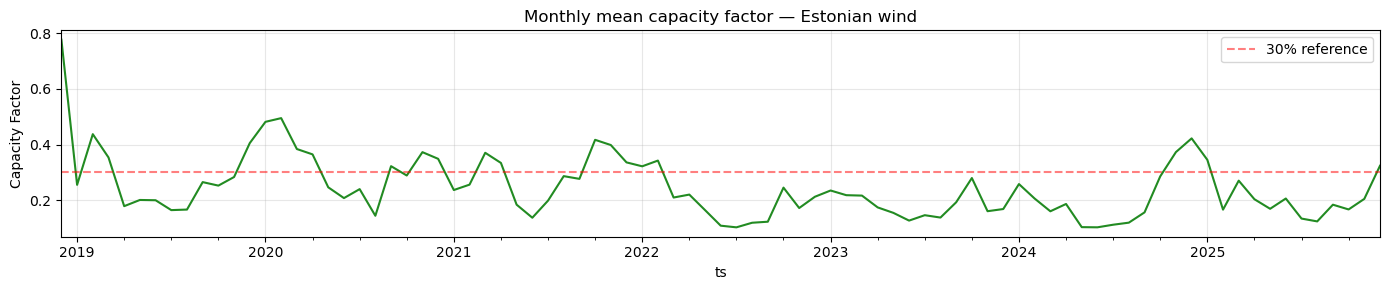

Capacity factor stats:
count    61327.000000
mean         0.237627
std          0.196541
min          0.000000
25%          0.081988
50%          0.179355
75%          0.347097
max          0.976129
dtype: float64


In [95]:
# 1f. Approximate installed capacity series → compute capacity factor
# ENTSOE gives actual production (MW), not installed capacity.
# Piecewise approximation based on public data (Elering annual reports).
capacity_history = pd.Series({
    pd.Timestamp("2019-01-01", tz="UTC"): 310,
    pd.Timestamp("2022-01-01", tz="UTC"): 403,
    pd.Timestamp("2023-01-01", tz="UTC"): 500,
    pd.Timestamp("2024-01-01", tz="UTC"): 640,
    pd.Timestamp("2025-01-01", tz="UTC"): 694,
}, name="installed_mw")

installed = capacity_history.reindex(wind.index, method="ffill").fillna(310)
capacity_factor = (wind / installed).clip(0, 1)

fig, ax = plt.subplots(figsize=(14, 3))
capacity_factor.resample("ME").mean().plot(
    ax=ax,
    title="Monthly mean capacity factor — Estonian wind",
    color="forestgreen"
)
ax.set_ylabel("Capacity Factor")
ax.axhline(0.30, color="red", linestyle="--", alpha=0.5, label="30% reference")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Capacity factor stats:")
print(capacity_factor.describe())

### Step 1f — Installed capacity and capacity factor

**Why we need this.** ENTSOE gives *actual production in MW* — it doesn't tell us what fraction of potential the wind fleet was running at. Next phase needs to know the **capacity factor** (CF) — the ratio of actual production to installed capacity — to validate that the weather-derived counterfactual estimates are in a plausible range.

**CF = actual production MW ÷ installed capacity MW**, clipped to [0, 1].

**The installed capacity series** is a piecewise approximation based on publicly reported grid connection data (Elering annual reports and Eleringi tuuleenergia statistika):
- 2019: ~310 MW
- 2022: ~403 MW
- 2023: ~500 MW
- 2024: ~640 MW
- 2025: ~694 MW

These are approximations — exact turbine commissioning dates are not needed for this analysis, since Phase 3 uses the CF range as a *plausibility check*, not a precise calculation. The counterfactual uses ERA5 weather + power curve directly, independent of these historical CF values.

**What to look for in the CF plot:** monthly CF should average around 25–35% in winter and 10–20% in summer, consistent with typical Baltic onshore wind. Values consistently near 1.0 would suggest the installed capacity estimate is too low; values near 0 would suggest the opposite.


In [96]:
# Save capacity factor alongside production for Phase 3 use
production["capacity_factor"] = capacity_factor
production["installed_mw"] = installed

# 1g. Save
out_path = "../data/entsoe_production_hourly.csv"
production.to_csv(out_path)
print(f"Saved {out_path}")
print(f"Shape: {production.shape}")
print(f"Columns: {list(production.columns)}")

Saved ../data/entsoe_production_hourly.csv
Shape: (61368, 13)
Columns: ['biomass', 'fossil_coal-derived_gas', 'fossil_gas', 'fossil_oil_shale', 'fossil_peat', 'hydro_run-of-river_and_pondage', 'other', 'other_renewable', 'solar', 'waste', 'wind_onshore', 'capacity_factor', 'installed_mw']


### Step 1g — Save

`entsoe_production_hourly.csv` is saved with a UTC datetime index and all production columns retained (biomass, solar, fossil types, etc.) even though only `wind_onshore` is used as a GNN feature. The extras are kept for potential EDA — e.g. checking how much fossil oil shale was running during the Jan 2026 crisis, or whether solar was genuinely zero.

Two extra columns are written alongside the production data:
- `capacity_factor`: the wind CF series computed in step 1f — used in Phase 3 to validate that the weather-derived counterfactual CF is in a plausible range.
- `installed_mw`: the piecewise capacity series — kept for reference and reproducibility.

---
## EDA — Estonian Energy Production Mix

Two overview plots built from the ENTSOE data:

1. **Annual energy mix (2019–2025)** — how the composition of Estonian generation has shifted over the training period. Fossil oil shale has historically dominated; wind and biomass have been growing. This gives context for why the Jan 2026 crisis was so severe: the grid still depended heavily on dispatchable fossil capacity that can be priced strategically.

2. **January 2026 hour-by-hour breakdown** — the actual energy mix during the crisis month, loaded from the 2026 ENTSOE file. Note that this file uses **15-minute resolution** (ENTSOE switched from hourly to 15-minute reporting), so it is resampled to hourly before plotting. This plot shows what was actually running when prices spiked — how much wind, how much oil shale, and whether any other sources compensated.

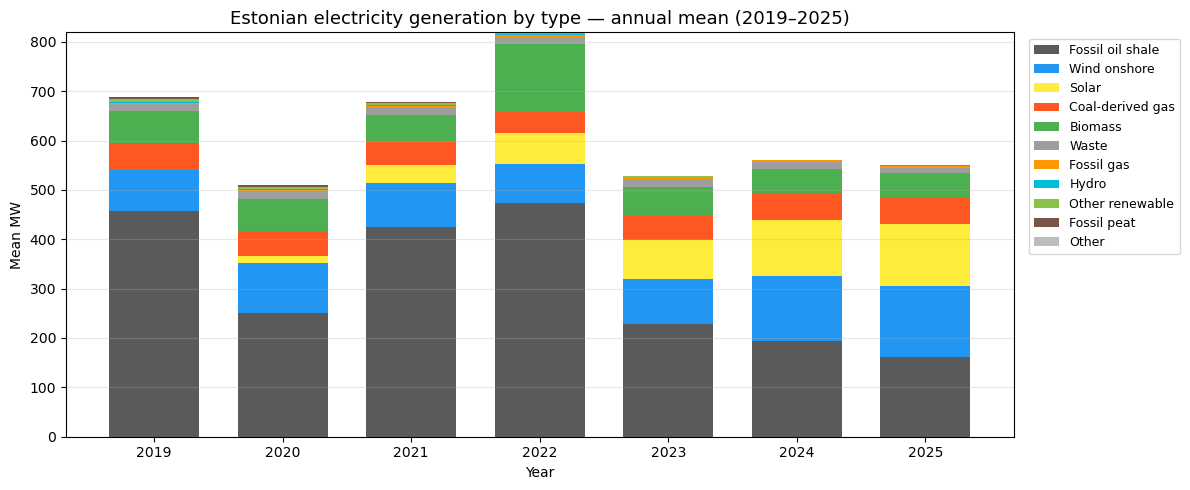

Annual mean generation (MW) by type:
ptype  Fossil oil shale  Wind onshore  Solar  Coal-derived gas  Biomass  Waste  Fossil gas  Hydro  Other renewable  Fossil peat  Other
ts                                                                                                                                    
2019              458.2          81.2    1.0              55.2     65.2   13.4         1.9    2.5              5.8          4.1    0.0
2020              250.7         100.3   14.6              50.7     65.6   15.3         2.9    1.5              4.6          3.1    0.0
2021              424.9          88.6   37.5              46.8     53.6   15.5         2.8    2.1              4.6          2.1    0.0
2022              474.0          78.1   63.8              41.6    137.6   14.0         3.9    2.1              3.1          1.0    0.0
2023              227.9          91.8   79.1              51.4     56.3   15.1         5.0    0.6              0.9          0.0    0.0
2024              

In [99]:
# --- Plot 1: Annual mean energy mix 2019–2025 ---
# Use the production DataFrame already in memory (from Phase 1).
# Drop helper columns, keep only generation types, compute annual means.

gen_cols = [c for c in production.columns if c not in ("capacity_factor", "installed_mw")]

annual = (
    production[gen_cols]
    .loc["2019":"2025"]          # full training years only
    .resample("YE").mean()
)
annual.index = annual.index.year  # label as plain year integers

# Friendly display names and colour palette
RENAME = {
    "fossil_oil_shale":              "Fossil oil shale",
    "biomass":                       "Biomass",
    "wind_onshore":                  "Wind onshore",
    "fossil_gas":                    "Fossil gas",
    "fossil_peat":                   "Fossil peat",
    "waste":                         "Waste",
    "other_renewable":               "Other renewable",
    "other":                         "Other",
    "solar":                         "Solar",
    "hydro_run-of-river_and_pondage": "Hydro",
    "fossil_coal-derived_gas":       "Coal-derived gas",
}
COLORS = {
    "Fossil oil shale": "#5a5a5a",
    "Biomass":          "#4caf50",
    "Wind onshore":     "#2196f3",
    "Fossil gas":       "#ff9800",
    "Fossil peat":      "#795548",
    "Waste":            "#9e9e9e",
    "Other renewable":  "#8bc34a",
    "Other":            "#bdbdbd",
    "Solar":            "#ffeb3b",
    "Hydro":            "#00bcd4",
    "Coal-derived gas": "#ff5722",
}

annual_named = annual.rename(columns=RENAME).fillna(0)
# Sort columns by 2025 contribution (largest at bottom of stack)
col_order = annual_named.loc[2025].sort_values(ascending=False).index.tolist()
annual_named = annual_named[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(annual_named))
for col in col_order:
    vals = annual_named[col].values
    ax.bar(annual_named.index, vals, bottom=bottom,
           label=col, color=COLORS.get(col, "#aaaaaa"), width=0.7)
    bottom += vals

ax.set_title("Estonian electricity generation by type — annual mean (2019–2025)", fontsize=13)
ax.set_ylabel("Mean MW")
ax.set_xlabel("Year")
ax.set_xticks(annual_named.index)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Annual mean generation (MW) by type:")
print(annual_named.round(1).to_string())

January 2026 data: 744 hours, 12 types
Types: ['biomass', 'energy_storage', 'fossil_coal-derived_gas', 'fossil_gas', 'fossil_oil_shale', 'fossil_peat', 'hydro_run-of-river_and_pondage', 'other', 'other_renewable', 'solar', 'waste', 'wind_onshore']


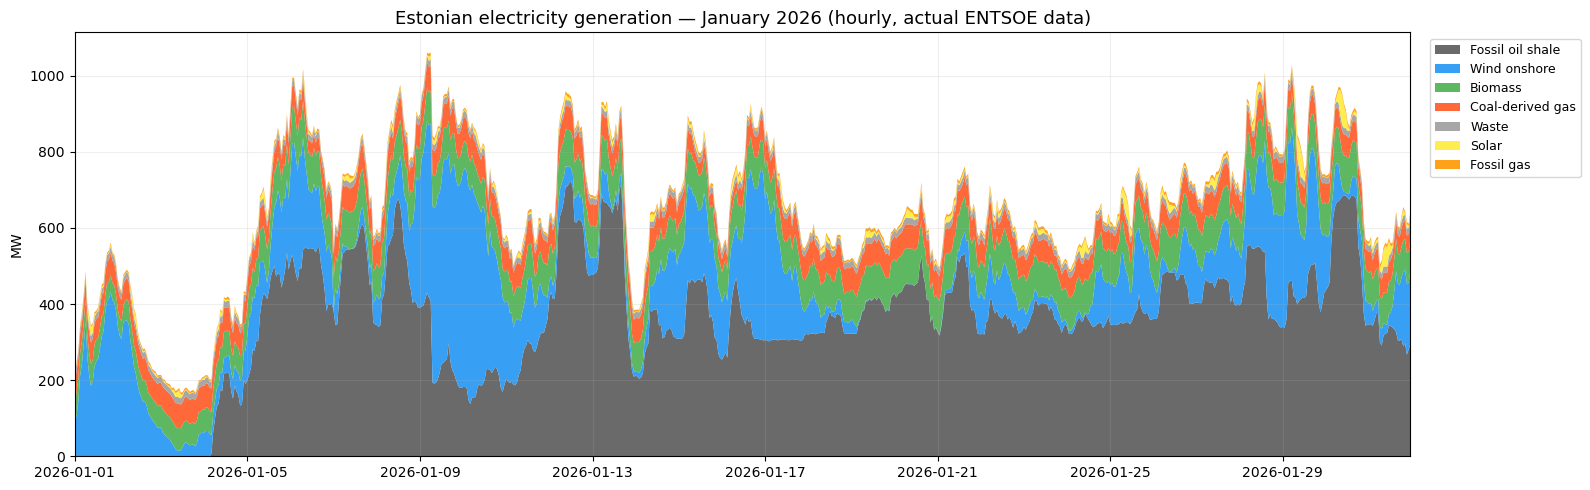


January 2026 mean generation by type (MW):
ptype
Fossil oil shale    352.4
Wind onshore        139.2
Biomass              83.4
Coal-derived gas     56.9
Waste                15.9
Solar                 6.4
Fossil gas            6.1


In [100]:
# --- Plot 2: January 2026 hourly energy mix (from 2026 ENTSOE file) ---
# The 2026 file covers from 2025-12-31 23:00 UTC onwards at 15-minute resolution
# (ENTSOE switched from hourly to 15-minute reporting).
# We apply the same ambiguous_arr DST fix as Phase 1 for robustness,
# then resample 15-min data to hourly before plotting.

F2026 = DATA_DIR + "2026_AGGREGATED_GENERATION_PER_TYPE_GENERATION_202512312300-202612312300.csv"

df26 = pd.read_csv(F2026, quotechar='"')
df26.columns = ["mtu", "area", "ptype", "mw"]

mtu_start26 = df26["mtu"].str.split(" - ").str[0]
is_standard26 = mtu_start26.str.contains(r"\(CET\)|\(EET\)", regex=True, na=False)
ambiguous_arr26 = np.where(is_standard26, False, True)

ts_clean26 = mtu_start26.str.replace(r"\s*\(\w+\)", "", regex=True).str.strip()
df26["ts"] = pd.to_datetime(ts_clean26, format="%d/%m/%Y %H:%M:%S")
df26["ts"] = (
    df26["ts"]
    .dt.tz_localize("Europe/Tallinn", ambiguous=ambiguous_arr26, nonexistent="shift_forward")
    .dt.tz_convert("UTC")
)
df26["mw"] = pd.to_numeric(df26["mw"], errors="coerce")

# Pivot and resample 15-min → hourly
prod26 = (
    df26[df26["ptype"] != "Wind Offshore"]
    .pivot_table(index="ts", columns="ptype", values="mw", aggfunc="mean")
    .sort_index()
)
prod26.columns = (
    prod26.columns.str.strip().str.lower()
    .str.replace(" ", "_", regex=False).str.replace("/", "_", regex=False)
)
prod26 = prod26.resample("h").mean()

# Filter to January 2026 only
jan26 = prod26.loc["2026-01-01":"2026-01-31"].copy()
print(f"January 2026 data: {jan26.shape[0]} hours, {jan26.shape[1]} types")
print("Types:", list(jan26.columns))

# Keep only types with mean > 1 MW to avoid clutter
jan26_plot = jan26.rename(columns=RENAME).fillna(0)
jan26_plot = jan26_plot[[c for c in jan26_plot.columns if jan26_plot[c].mean() > 1]]
col_order26 = jan26_plot.mean().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(16, 5))
ax.stackplot(
    jan26_plot.index,
    [jan26_plot[c].values for c in col_order26],
    labels=col_order26,
    colors=[COLORS.get(c, "#aaaaaa") for c in col_order26],
    alpha=0.9,
)
ax.set_title("Estonian electricity generation — January 2026 (hourly, actual ENTSOE data)", fontsize=13)
ax.set_ylabel("MW")
ax.set_xlim(jan26_plot.index[0], jan26_plot.index[-1])
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("\nJanuary 2026 mean generation by type (MW):")
print(jan26_plot[col_order26].mean().round(1).to_string())
